In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
# import climbasis as climb

# from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs 
from obsinfo import *
import mar
from scipy.stats import pearsonr

from matplotlib.cm import ScalarMappable
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
yr=2016## 01-10-2022
#fyr=2023 ## 30-09-2023
domain="GRf"
d='f'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)
variable='pr'
var='pr'
units='mm/day'
nx=15;ny=15

36 41 67 78


In [4]:
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/'+domain+'/sensitivity_tests/'



In [5]:
'''dsH_SF= dsH_SF1.assign_coords({
    'lat': (('y', 'x'), dsH_grid['LAT'].values),
    'lon': (('y', 'x'), dsH_grid['LON'].values)
})
dsH_RF= dsH_RF1.assign_coords({
    'lat': (('y', 'x'), dsH_grid['LAT'].values),
    'lon': (('y', 'x'), dsH_grid['LON'].values)
})
dsH=dsH_RF+dsH_SF'''

"dsH_SF= dsH_SF1.assign_coords({\n    'lat': (('y', 'x'), dsH_grid['LAT'].values),\n    'lon': (('y', 'x'), dsH_grid['LON'].values)\n})\ndsH_RF= dsH_RF1.assign_coords({\n    'lat': (('y', 'x'), dsH_grid['LAT'].values),\n    'lon': (('y', 'x'), dsH_grid['LON'].values)\n})\ndsH=dsH_RF+dsH_SF"

In [6]:
ds_RF_s2=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/'+domain+'/spin2/work/daily/'
                          +'RF_daysum_MARv3.14_ER5_spin2_'+domain+'_2016.nc')['RF']
##
ds_RF_30=xr.open_dataset(sourceData+'RF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'30.nc')['RF']
ds_RF_31=xr.open_dataset(sourceData+'RF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'31.nc')['RF']
ds_RF_32=xr.open_dataset(sourceData+'RF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'32.nc')['RF']
ds_RF_33=xr.open_dataset(sourceData+'RF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'33.nc')['RF']
ds_RF_34=xr.open_dataset(sourceData+'RF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'34.nc')['RF']
ds_RF_35=xr.open_dataset(sourceData+'RF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'35.nc')['RF']
ds_RF_36=xr.open_dataset(sourceData+'RF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'36.nc')['RF']
ds_RF_37=xr.open_dataset(sourceData+'RF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'37.nc')['RF']


In [7]:
ds_SF_s2=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/'+domain+'/spin2/work/daily/'
                          +'SF_daysum_MARv3.14_ER5_spin2_'+domain+'_2016.nc')['SF']
##
ds_SF_30=xr.open_dataset(sourceData+'SF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'30.nc')['SF']
ds_SF_31=xr.open_dataset(sourceData+'SF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'31.nc')['SF']
ds_SF_32=xr.open_dataset(sourceData+'SF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'32.nc')['SF']
ds_SF_33=xr.open_dataset(sourceData+'SF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'33.nc')['SF']
ds_SF_34=xr.open_dataset(sourceData+'SF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'34.nc')['SF']
ds_SF_35=xr.open_dataset(sourceData+'SF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'35.nc')['SF']
ds_SF_36=xr.open_dataset(sourceData+'SF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'36.nc')['SF']
ds_SF_37=xr.open_dataset(sourceData+'SF_daysum_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'37.nc')['SF']


In [8]:
ds_RF_gc=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRi/spin1/'
                          +'RF_daysum_MARv3.14_ER5_spin1_GRi_2016.i15.nc')['RF']
ds_RF_gd=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRj/spin1/'
                          +'RF_daysum_MARv3.14_ER5_spin1_GRj_2016.j15.nc')['RF']

ds_RF_ge=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRk/spin1/'
                          +'RF_daysum_MARv3.14_ER5_spin1_GRk_2016.k15.nc')['RF']


In [9]:
ds_SF_gc=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRi/spin1/'
                          +'SF_daysum_MARv3.14_ER5_spin1_GRi_2016.i15.nc')['SF']
ds_SF_gd=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRj/spin1/'
                          +'SF_daysum_MARv3.14_ER5_spin1_GRj_2016.j15.nc')['SF']

ds_SF_ge=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRk/spin1/'
                          +'SF_daysum_MARv3.14_ER5_spin1_GRk_2016.k15.nc')['SF']


In [10]:
##season

ds_RF_s2_per=ds_RF_s2[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
##
ds_RF_30_per=ds_RF_30[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_RF_31_per=ds_RF_31[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_RF_32_per=ds_RF_32[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_RF_33_per=ds_RF_33[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_RF_34_per=ds_RF_34[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_RF_35_per=ds_RF_35[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_RF_36_per=ds_RF_36[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_RF_37_per=ds_RF_37[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')

ds_SF_s2_per=ds_SF_s2[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
##
ds_SF_30_per=ds_SF_30[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_SF_31_per=ds_SF_31[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_SF_32_per=ds_SF_32[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_SF_33_per=ds_SF_33[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_SF_34_per=ds_SF_34[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_SF_35_per=ds_SF_35[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_SF_36_per=ds_SF_36[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_SF_37_per=ds_SF_37[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')


In [11]:
ds_RF_gc_per=ds_RF_gc[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_RF_gd_per=ds_RF_gd[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_RF_ge_per=ds_RF_ge[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')


ds_SF_gc_per=ds_SF_gc[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_SF_gd_per=ds_SF_gd[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')
ds_SF_ge_per=ds_SF_ge[:,ny:-ny,nx:-nx].groupby('TIME.season').mean('TIME')


In [12]:
model7='chirps'
ds_obs= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/'+model7+'/daily/'+'chirps-v2.0.2016.days_p05_HMA.nc')['precip']
field_obs=dom.field_dom(ds_obs,domain)
ds_obs_per=field_obs.groupby('time.season').mean('time')

In [13]:
modelList=['obs','spin2','30','31','32','33','34','35','36','37','gc','gd','ge']

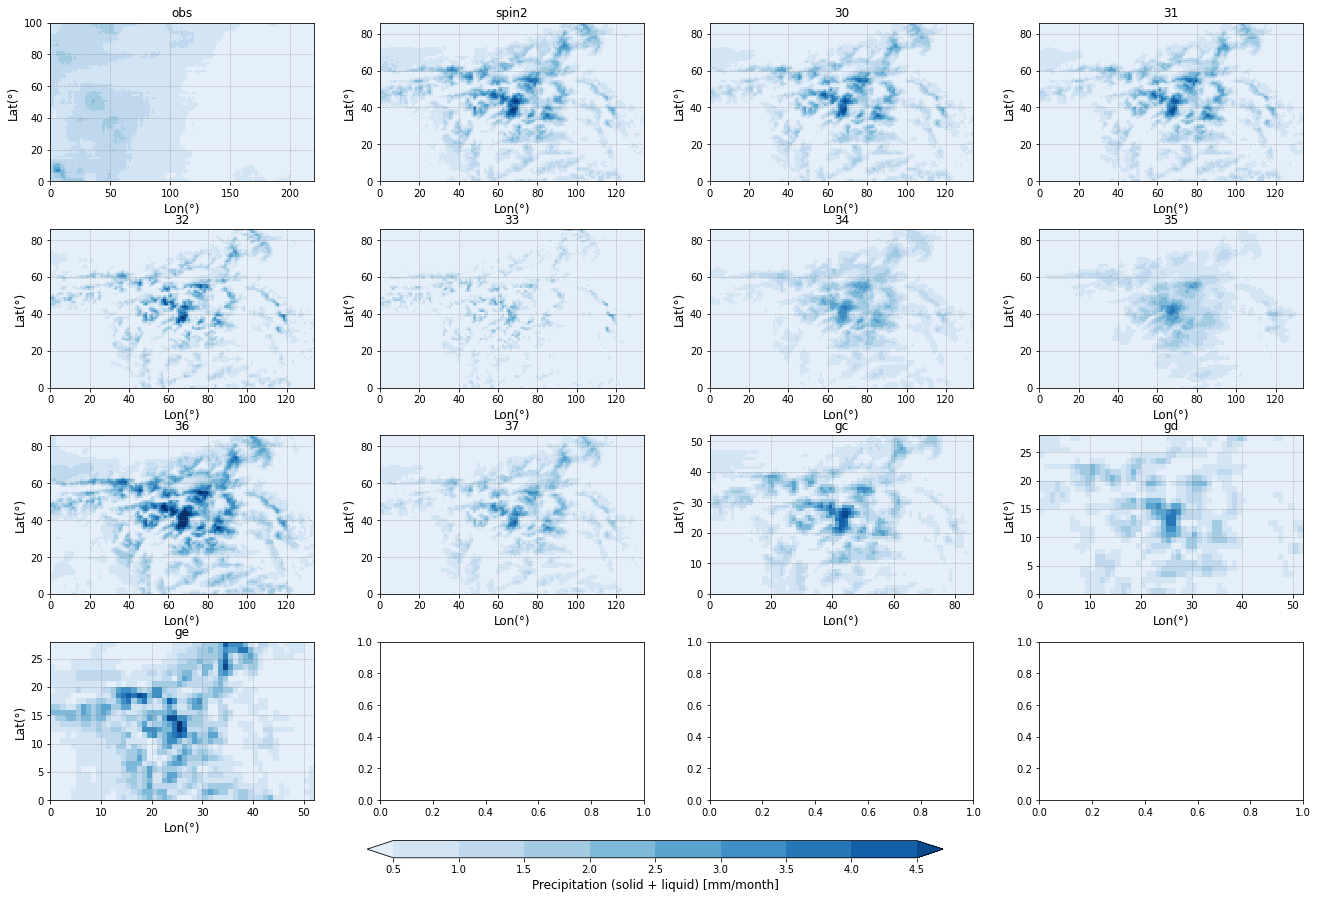

In [14]:
season='DJF'
plotList=[ds_obs_per.sel(season=season),
          ds_RF_s2_per.sel(season=season)+ds_SF_s2_per.sel(season=season),
          ds_RF_30_per.sel(season=season)+ds_SF_30_per.sel(season=season),
          ds_RF_31_per.sel(season=season)+ds_SF_31_per.sel(season=season),
          ds_RF_32_per.sel(season=season)+ds_SF_32_per.sel(season=season),
          ds_RF_33_per.sel(season=season)+ds_SF_33_per.sel(season=season),
          ds_RF_34_per.sel(season=season)+ds_SF_34_per.sel(season=season),
          ds_RF_35_per.sel(season=season)+ds_SF_35_per.sel(season=season),
         ds_RF_36_per.sel(season=season)+ds_SF_36_per.sel(season=season),
         ds_RF_37_per.sel(season=season)+ds_SF_37_per.sel(season=season),
         ds_RF_gc_per.sel(season=season)+ds_SF_gc_per.sel(season=season),
         ds_RF_gd_per.sel(season=season)+ds_SF_gd_per.sel(season=season),
         ds_RF_ge_per.sel(season=season)+ds_SF_ge_per.sel(season=season)]
##
clevs=np.arange(0,5.5,0.5);
cmap = plt.get_cmap("Blues")
#norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=4
ncols=4

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title(modelList[i] )
#fig.suptitle(title,y=0.9)
fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
#axs[10].remove()   
#axs[11].remove()   

# --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=clevs, spacing='proportional')
cbar.set_label('Precipitation (solid + liquid) [mm/month]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
#plt.savefig(outputDir+title+'.png',bbox_inches='tight')
plt.show()

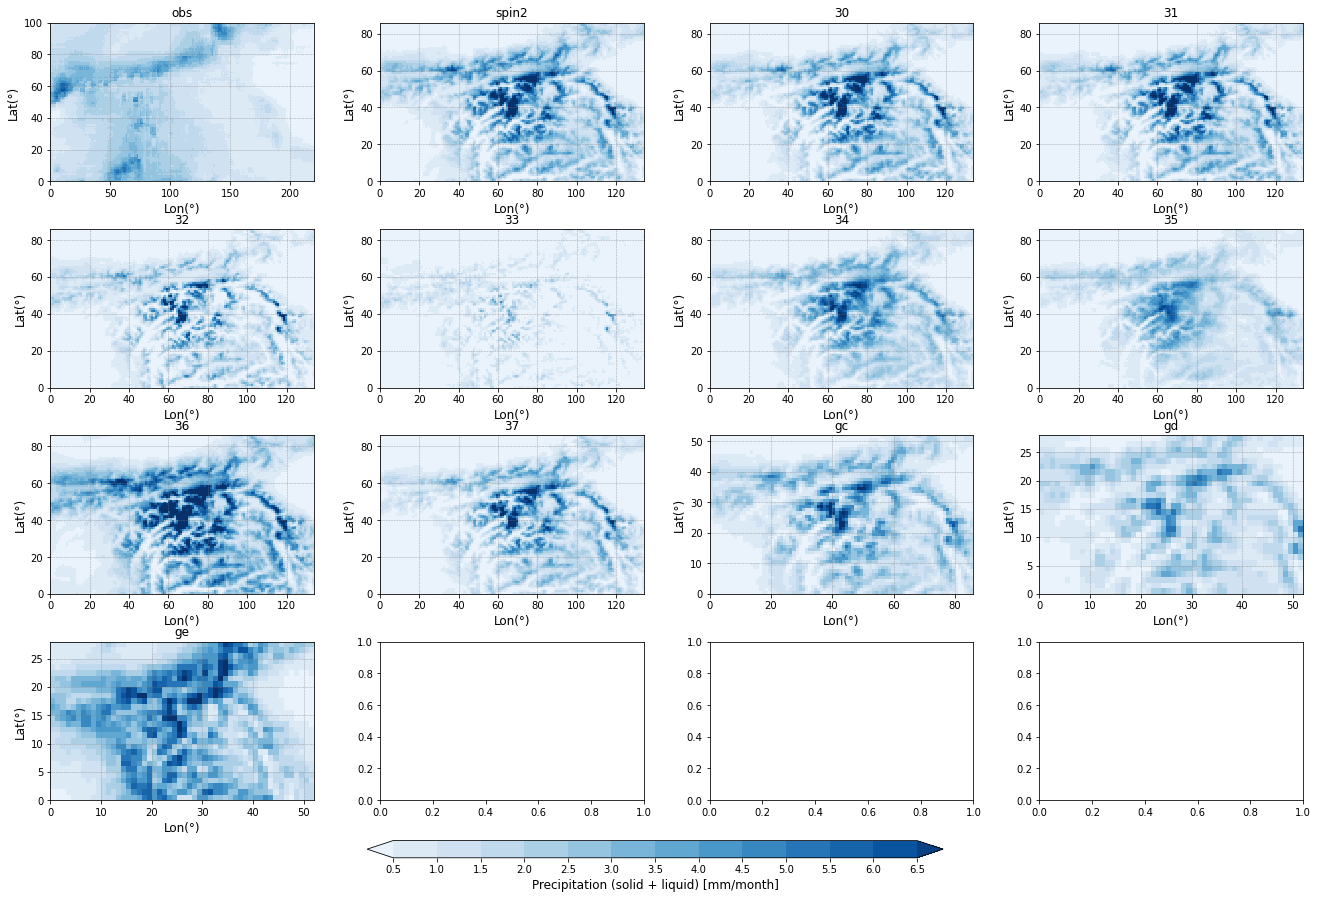

In [15]:
season='MAM'
plotList=[ds_obs_per.sel(season=season),
          ds_RF_s2_per.sel(season=season)+ds_SF_s2_per.sel(season=season),
          ds_RF_30_per.sel(season=season)+ds_SF_30_per.sel(season=season),
          ds_RF_31_per.sel(season=season)+ds_SF_31_per.sel(season=season),
          ds_RF_32_per.sel(season=season)+ds_SF_32_per.sel(season=season),
          ds_RF_33_per.sel(season=season)+ds_SF_33_per.sel(season=season),
          ds_RF_34_per.sel(season=season)+ds_SF_34_per.sel(season=season),
          ds_RF_35_per.sel(season=season)+ds_SF_35_per.sel(season=season),
         ds_RF_36_per.sel(season=season)+ds_SF_36_per.sel(season=season),
         ds_RF_37_per.sel(season=season)+ds_SF_37_per.sel(season=season),
         ds_RF_gc_per.sel(season=season)+ds_SF_gc_per.sel(season=season),
         ds_RF_gd_per.sel(season=season)+ds_SF_gd_per.sel(season=season),
         ds_RF_ge_per.sel(season=season)+ds_SF_ge_per.sel(season=season)]
##
clevs=np.arange(0,7.5,0.5);
cmap = plt.get_cmap("Blues")
#norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=4
ncols=4

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title(modelList[i] )
#fig.suptitle(title,y=0.9)
fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
#axs[10].remove()   
#axs[11].remove()   

# --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=clevs, spacing='proportional')
cbar.set_label('Precipitation (solid + liquid) [mm/month]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
#plt.savefig(outputDir+title+'.png',bbox_inches='tight')
plt.show()

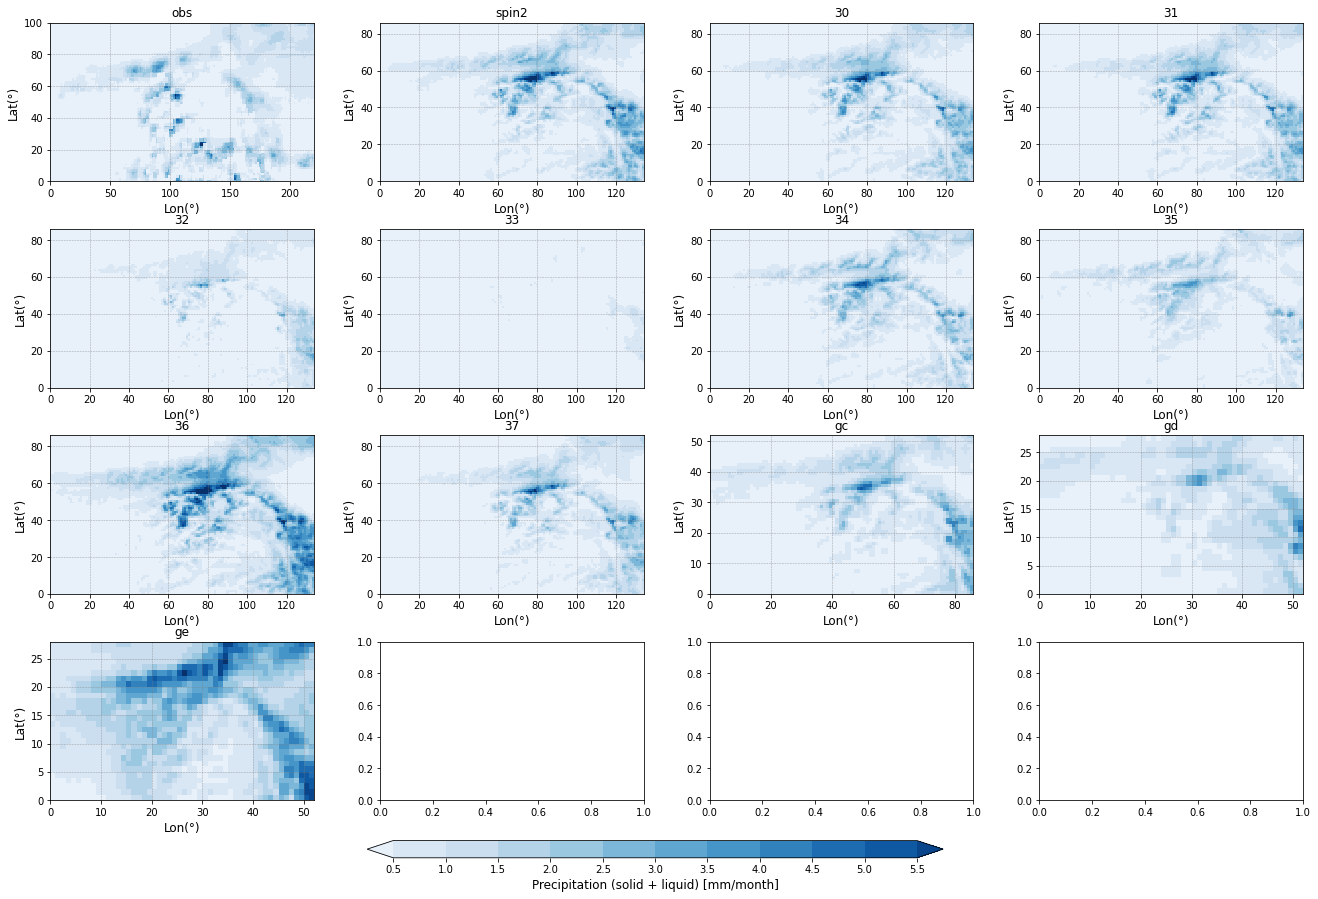

In [18]:
season='JJA'
plotList=[ds_obs_per.sel(season=season),
          ds_RF_s2_per.sel(season=season)+ds_SF_s2_per.sel(season=season),
          ds_RF_30_per.sel(season=season)+ds_SF_30_per.sel(season=season),
          ds_RF_31_per.sel(season=season)+ds_SF_31_per.sel(season=season),
          ds_RF_32_per.sel(season=season)+ds_SF_32_per.sel(season=season),
          ds_RF_33_per.sel(season=season)+ds_SF_33_per.sel(season=season),
          ds_RF_34_per.sel(season=season)+ds_SF_34_per.sel(season=season),
          ds_RF_35_per.sel(season=season)+ds_SF_35_per.sel(season=season),
         ds_RF_36_per.sel(season=season)+ds_SF_36_per.sel(season=season),
         ds_RF_37_per.sel(season=season)+ds_SF_37_per.sel(season=season),
         ds_RF_gc_per.sel(season=season)+ds_SF_gc_per.sel(season=season),
         ds_RF_gd_per.sel(season=season)+ds_SF_gd_per.sel(season=season),
         ds_RF_ge_per.sel(season=season)+ds_SF_ge_per.sel(season=season)]
##
clevs=np.arange(0,6.5,0.5);
cmap = plt.get_cmap("Blues")
#norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=4
ncols=4

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title(modelList[i] )
#fig.suptitle(title,y=0.9)
fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
#axs[10].remove()   
#axs[11].remove()   

# --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=clevs, spacing='proportional')
cbar.set_label('Precipitation (solid + liquid) [mm/month]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
#plt.savefig(outputDir+title+'.png',bbox_inches='tight')
plt.show()


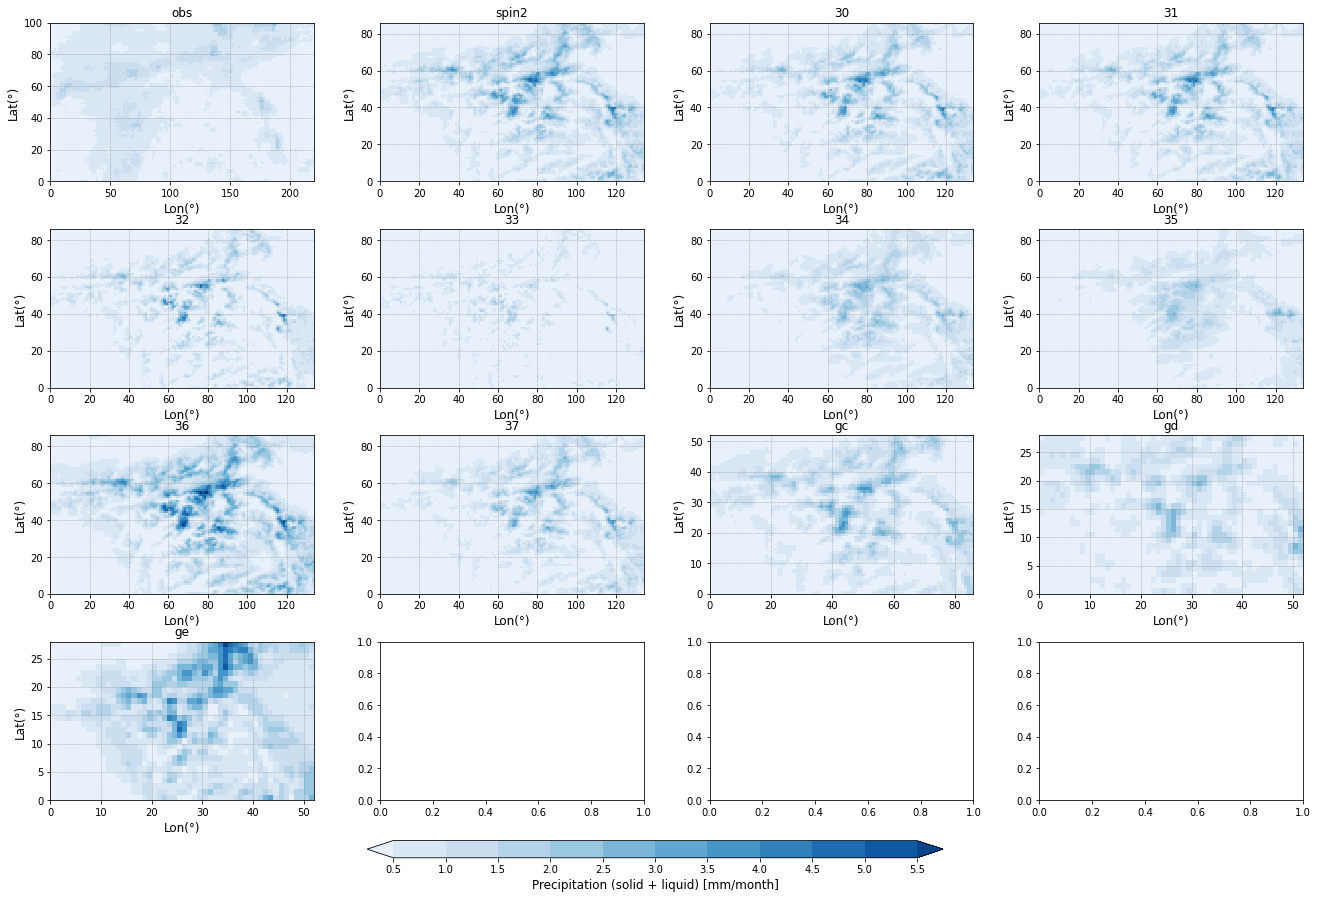

In [19]:
season='SON'
plotList=[ds_obs_per.sel(season=season),
          ds_RF_s2_per.sel(season=season)+ds_SF_s2_per.sel(season=season),
          ds_RF_30_per.sel(season=season)+ds_SF_30_per.sel(season=season),
          ds_RF_31_per.sel(season=season)+ds_SF_31_per.sel(season=season),
          ds_RF_32_per.sel(season=season)+ds_SF_32_per.sel(season=season),
          ds_RF_33_per.sel(season=season)+ds_SF_33_per.sel(season=season),
          ds_RF_34_per.sel(season=season)+ds_SF_34_per.sel(season=season),
          ds_RF_35_per.sel(season=season)+ds_SF_35_per.sel(season=season),
         ds_RF_36_per.sel(season=season)+ds_SF_36_per.sel(season=season),
         ds_RF_37_per.sel(season=season)+ds_SF_37_per.sel(season=season),
         ds_RF_gc_per.sel(season=season)+ds_SF_gc_per.sel(season=season),
         ds_RF_gd_per.sel(season=season)+ds_SF_gd_per.sel(season=season),
         ds_RF_ge_per.sel(season=season)+ds_SF_ge_per.sel(season=season)]
##
clevs=np.arange(0,6.5,0.5);
cmap = plt.get_cmap("Blues")
#norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=4
ncols=4

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title(modelList[i] )
#fig.suptitle(title,y=0.9)
fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
#axs[10].remove()   
#axs[11].remove()   

# --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=clevs, spacing='proportional')
cbar.set_label('Precipitation (solid + liquid) [mm/month]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
#plt.savefig(outputDir+title+'.png',bbox_inches='tight')
plt.show()


In [20]:
tt=field_obs.mean('longitude')
ts_obs=tt.mean('latitude')


In [21]:
ts_RF_s2=ds_RF_s2.mean('X').mean('Y')
ts_RF_30=ds_RF_30.mean('X').mean('Y')
ts_RF_31=ds_RF_31.mean('X').mean('Y')
ts_RF_32=ds_RF_32.mean('X').mean('Y')
ts_RF_33=ds_RF_33.mean('X').mean('Y')
ts_RF_34=ds_RF_34.mean('X').mean('Y')
ts_RF_35=ds_RF_35.mean('X').mean('Y')
ts_RF_36=ds_RF_36.mean('X').mean('Y')
ts_RF_37=ds_RF_37.mean('X').mean('Y')

In [22]:
ts_SF_s2=ds_SF_s2.mean('X').mean('Y')
ts_SF_30=ds_SF_30.mean('X').mean('Y')
ts_SF_31=ds_SF_31.mean('X').mean('Y')
ts_SF_32=ds_SF_32.mean('X').mean('Y')
ts_SF_33=ds_SF_33.mean('X').mean('Y')
ts_SF_34=ds_SF_34.mean('X').mean('Y')
ts_SF_35=ds_SF_35.mean('X').mean('Y')
ts_SF_36=ds_SF_36.mean('X').mean('Y')
ts_SF_37=ds_SF_37.mean('X').mean('Y')

In [23]:
ts_RF_gc=ds_RF_gc.mean('X').mean('Y')
ts_RF_gd=ds_RF_gd.mean('X').mean('Y')
ts_RF_ge=ds_RF_ge.mean('X').mean('Y')


In [24]:
ts_SF_gc=ds_SF_gc.mean('X').mean('Y')
ts_SF_gd=ds_SF_gd.mean('X').mean('Y')
ts_SF_ge=ds_SF_ge.mean('X').mean('Y')


In [25]:
tsList=[ts_SF_s2+ts_RF_s2,
        ts_RF_30+ts_SF_30,ts_RF_31+ts_SF_31,ts_RF_32+ts_SF_32,
       ts_RF_33+ts_SF_33,ts_RF_34+ts_SF_34,ts_RF_35+ts_SF_35,
        ts_RF_36+ts_SF_36,ts_RF_37+ts_SF_37,
        ts_RF_gc+ts_SF_gc,ts_RF_gd+ts_SF_gd,ts_RF_ge+ts_SF_ge
       ]


corrList=[]
rmseList=[]
for i in range(len(tsList)):
    tmp=np.corrcoef(ts_obs,tsList[i])[0,1]
    rmse = np.sqrt(np.nanmean((ts_obs - tsList[i])**2))
    corrList.append(round(tmp,2))
    rmseList.append(round(rmse,2))

In [30]:
colorList=['red','orange','blue','brown','fuchsia','purple','grey','pink','black','black','black']

In [27]:
print(corrList),print(np.arange(30,30+len(corrList)-1,1))
print(rmseList),print(np.arange(30,30+len(rmseList)-1,1))

[6.2e-01, 0.59, 0.58, 0.59, 0.53, 0.55, 0.59, 0.68, 0.54, 0.59, 0.54, 0.51]
[30 31 32 33 34 35 36 37 38 39 40]
[1.51, 1.46, 1.46, 1.44, 1.45, 1.43, 1.41, 1.67, 1.44, 1.47, 1.43, 1.63]
[30 31 32 33 34 35 36 37 38 39 40]


(None, None)

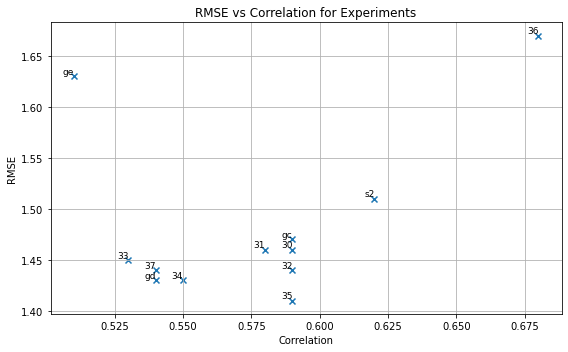

In [28]:
labels = ["s2", "30", "31", "32", "33", "34", "35", "36", "37","gc","gd","ge"]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(corrList, rmseList, marker="x")

# Add experiment labels next to each point
for x, y, label in zip(corrList, rmseList, labels):
    ax.text(x, y, label, fontsize=9, ha="right", va="bottom")

ax.set_xlabel("Correlation")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs Correlation for Experiments")
ax.grid(True)
fig.tight_layout()

In [26]:
from datetime import datetime

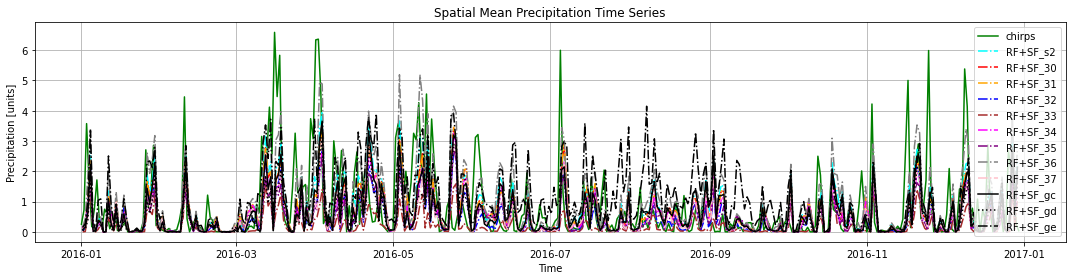

In [31]:
imon=1
fmon=12
fig=plt.figure(figsize=(15, 4))

#plt.plot(ts_RF_30.TIME,ts_obs,label='chirps',color='green')
#


plt.plot(ts_obs.time.sel(time=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         ts_obs.sel(time=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='chirps',linestyle='-',color='green')
##
plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_s2+ts_SF_s2).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_s2',linestyle='-.',color='cyan')

##
plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_30+ts_SF_30).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_30',linestyle='-.',color=colorList[0])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_31+ts_SF_31).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_31',linestyle='-.',color=colorList[1])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_32+ts_SF_32).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_32',linestyle='-.',color=colorList[2])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_33+ts_SF_33).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_33',linestyle='-.',color=colorList[3])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_34+ts_SF_34).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_34',linestyle='-.',color=colorList[4])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_35+ts_SF_35).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_35',linestyle='-.',color=colorList[5])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_36+ts_SF_36).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_36',linestyle='-.',color=colorList[6])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_37+ts_SF_37).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_37',linestyle='-.',color=colorList[7])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016,imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_gc+ts_SF_gc).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_gc',linestyle='-',color=colorList[8])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016,imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_gd+ts_SF_gd).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_gd',linestyle=':',color=colorList[8])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016,imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_ge+ts_SF_ge).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_ge',linestyle='-.',color=colorList[8])

# Plot formatting
plt.xlabel('Time')
plt.ylabel('Precipitation [units]')  # Update with correct units
plt.title('Spatial Mean Precipitation Time Series')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

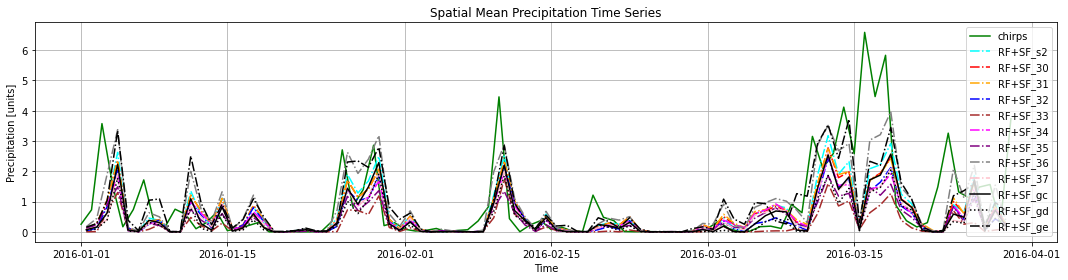

In [32]:
imon=1
fmon=3
fig=plt.figure(figsize=(15, 4))

#plt.plot(ts_RF_30.TIME,ts_obs,label='chirps',color='green')
#


plt.plot(ts_obs.time.sel(time=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         ts_obs.sel(time=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='chirps',linestyle='-',color='green')
##
plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_s2+ts_SF_s2).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_s2',linestyle='-.',color='cyan')

##
plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_30+ts_SF_30).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_30',linestyle='-.',color=colorList[0])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_31+ts_SF_31).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_31',linestyle='-.',color=colorList[1])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_32+ts_SF_32).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_32',linestyle='-.',color=colorList[2])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_33+ts_SF_33).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_33',linestyle='-.',color=colorList[3])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_34+ts_SF_34).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_34',linestyle='-.',color=colorList[4])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_35+ts_SF_35).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_35',linestyle='-.',color=colorList[5])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_36+ts_SF_36).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_36',linestyle='-.',color=colorList[6])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_37+ts_SF_37).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_37',linestyle='-.',color=colorList[7])


plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016,imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_gc+ts_SF_gc).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_gc',linestyle='-',color=colorList[8])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016,imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_gd+ts_SF_gd).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_gd',linestyle=':',color=colorList[8])

plt.plot((ts_RF_30+ts_SF_30).TIME.sel(TIME=slice(datetime(2016,imon, 1),datetime(2016, fmon, 30))),
         (ts_RF_ge+ts_SF_ge).sel(TIME=slice(datetime(2016, imon, 1),datetime(2016, fmon, 30))),
         label='RF+SF_ge',linestyle='-.',color=colorList[8])

# Plot formatting
plt.xlabel('Time')
plt.ylabel('Precipitation [units]')  # Update with correct units
plt.title('Spatial Mean Precipitation Time Series')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
## Model MAR
model='MAR'
sourceDataGrid='/home/amoryc/'
fileName_gr='NST.2000.01.01.00.GRa_Fedchenko.nc_ICEmask'
#fileName_gr='NST.2000.01.01.00.GRa_Mera.nc_ICEmask'
ds_grM= xr.open_dataset(sourceDataGrid+fileName_gr)
dsSH=ds_grM['SH']

elev_flat = dsSH.values.flatten()
###Bin elevation (interval 250 m)
elev_bins = np.arange(0, np.max(elev_flat) + 250, 250)
elev_bin_labels = (elev_bins[:-1] + elev_bins[1:]) / 2

In [34]:
dsList=[ds_RF_s2+ds_SF_s2,
        ds_RF_30+ds_SF_30,
       ds_RF_31+ds_SF_31,
        ds_RF_32+ds_SF_32,
       ds_RF_33+ds_SF_33,
        ds_RF_34+ds_SF_34,
        ds_RF_35+ds_SF_35,
        ds_RF_36+ds_SF_36,
        ds_RF_37+ds_SF_37
       ]

In [35]:
mean_precip_by_elev_List=[]

for elem in dsList:
    precip_flat = elem.mean('TIME').values.flatten()
    df = pd.DataFrame({'elevation': elev_flat, 'precip': precip_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_precip_by_elev = df.groupby('elev_bin')['precip'].mean()
    mean_precip_by_elev_List.append(mean_precip_by_elev)    

In [37]:
ds_gc=ds_RF_gc+ds_SF_gc
dsSH_gc= xr.open_dataset('/home/amoryc/NST.2014.01.01.00.GRi.nc')['SH']
elev_flat_gc=dsSH_gc.values.flatten()
precip_flat_gc = ds_gc.mean('TIME').values.flatten()
df_gc = pd.DataFrame({'elevation': elev_flat_gc, 'precip': precip_flat_gc})
df_gc['elev_bin'] = pd.cut(df_gc['elevation'], bins=elev_bins, labels=elev_bin_labels)
mean_precip_by_elev_gc = df_gc.groupby('elev_bin')['precip'].mean()

       
        

In [38]:
ds_gd=ds_RF_gd+ds_SF_gd
dsSH_gd= xr.open_dataset('/home/amoryc/NST.2014.01.01.00.GRj.nc')['SH']
elev_flat_gd=dsSH_gd.values.flatten()
precip_flat_gd = ds_gd.mean('TIME').values.flatten()
df_gd = pd.DataFrame({'elevation': elev_flat_gd, 'precip': precip_flat_gd})
df_gd['elev_bin'] = pd.cut(df_gd['elevation'], bins=elev_bins, labels=elev_bin_labels)
mean_precip_by_elev_gd = df_gd.groupby('elev_bin')['precip'].mean()


In [39]:
ds_ge=ds_RF_ge+ds_SF_ge
dsSH_ge= xr.open_dataset('/home/amoryc/NST.2014.01.01.00.GRk.nc')['SH']
elev_flat_ge=dsSH_ge.values.flatten()
precip_flat_ge = ds_ge.mean('TIME').values.flatten()
df_ge = pd.DataFrame({'elevation': elev_flat_ge, 'precip': precip_flat_ge})
df_ge['elev_bin'] = pd.cut(df_ge['elevation'], bins=elev_bins, labels=elev_bin_labels)
mean_precip_by_elev_ge = df_ge.groupby('elev_bin')['precip'].mean()


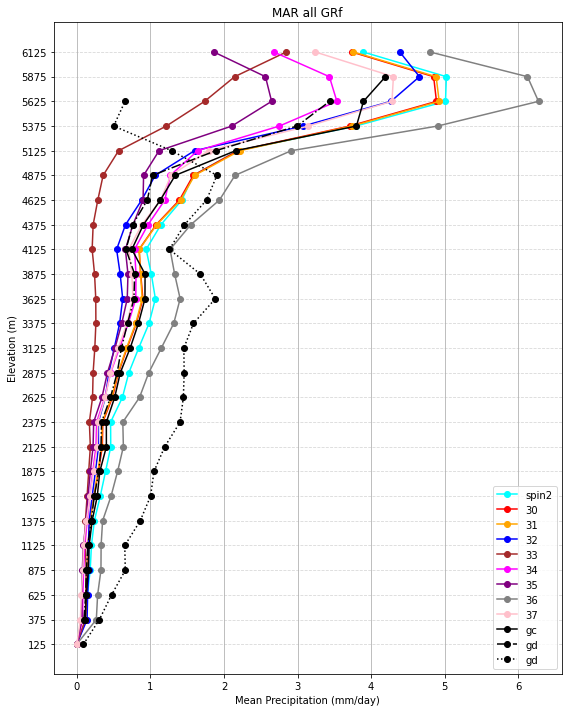

In [40]:

fig=plt.figure(figsize=(8, 10))

plt.plot(mean_precip_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan',
         label=modelList[1+0])

for i in np.arange(1,len(dsList[1:])+1,1):
                   
    plt.plot(mean_precip_by_elev_List[i].values,elev_bin_labels, marker='o',color=colorList[i-1],
         label=modelList[1+i])
    
plt.plot(mean_precip_by_elev_gc.values,elev_bin_labels, marker='o',color='black',
         label=modelList[len(dsList[1:])+2])

plt.plot(mean_precip_by_elev_gd.values,elev_bin_labels, linestyle='-.',marker='o',color='black',
         label=modelList[len(dsList[1:])+3])

plt.plot(mean_precip_by_elev_ge.values,elev_bin_labels, linestyle=':',marker='o',color='black',
         label=modelList[len(dsList[1:])+3])


             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.ylabel('Elevation (m)')
plt.xlabel('Mean Precipitation (mm/day)')
plt.title('MAR all ' +domain)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#precip_flat_obs = ds_obs.mean('time').values.flatten()
#df_obs = pd.DataFrame({'elevation': elev_flat, 'precip': precip_flat_obs})
#df_obs['elev_bin'] = pd.cut(df_obs['elevation'], bins=elev_bins, labels=elev_bin_labels)
#mean_precip_by_elev_obs = df_obs.groupby('elev_bin')['precip'].mean()
#mean_precip_by_elev_List_DJF.append(mean_precip_by_elev)

In [ ]:
#plt.plot(mean_precip_by_elev, elev_bin_labels,
#                color='red', marker='o', linestyle='-')# Figure title and layout
#plt.show()